In [1]:
import cv2
import time
import numpy as np
from IPython.display import Video
from IPython.display import display, clear_output
import matplotlib.pyplot as plt
import pandas as pd
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from torchvision.models.segmentation import deeplabv3_resnet50
from torchvision.models.segmentation.deeplabv3 import DeepLabHead

In [2]:
img_root = "C:\\Facultate\\Facultate\\Anul 3\\Semestrul 1\\KBS\\Proiect\\archive\\images"
label_root = "C:\\Facultate\\Facultate\\Anul 3\\Semestrul 1\\KBS\\Proiect\\archive\\labels"

In [3]:
classes_rgb = pd.read_csv(r"C:\\Facultate\\Facultate\\Anul 3\\Semestrul 1\\KBS\\Proiect\\archive\\classes_rgb_values.csv")
video_info = pd.read_csv(r"C:\\Facultate\\Facultate\\Anul 3\\Semestrul 1\\KBS\\Proiect\\archive\\video_info.csv")
rgb_values = np.array(classes_rgb["rgb_values"].apply(eval).tolist())

video_groups = video_info.groupby(["weather", "driving_scenario"])["Index"].apply(list)

In [4]:
# Function - creating the classId matrix
num_classes = len(rgb_values)
unknown_id = 12

def classid(label_rgb, rgb_values):
    h, w, _ = label_rgb.shape
    label_flat = label_rgb.reshape(-1, 3)

    class_ids = np.zeros((label_flat.shape[0],), dtype=np.uint8)

    for idx, rgb in enumerate(rgb_values):
        mask = np.all(label_flat == rgb, axis=1)
        class_ids[mask] = idx

    return class_ids.reshape(h, w)

In [5]:
# Generating a list with all frames
video_names = sorted(os.listdir(img_root))
video_frames = [] # list of (video, (image_path, label_path))

for vid in video_names:
    img_dir = os.path.join(img_root, vid)
    label_dir = os.path.join(label_root, vid)

    frame_names = sorted(os.listdir(img_dir))

    frames = []

    for name in frame_names:
        img_path = os.path.join(img_dir, name)
        label_path = os.path.join(label_dir, name)

        if os.path.isfile(img_path) and os.path.isfile(label_path):
            frames.append((img_path, label_path))
    video_frames.append(frames)

In [6]:
import random
random.seed(42)

train_videos = []
val_videos = []

for (weather, scenario), vids in video_groups.items():
    vids = vids.copy()
    random.shuffle(vids)
    
    n = len(vids)
    
    if n == 1:
        train_videos.append(vids[0])
    else:
        n_val = max(1, int(round(0.3 * n)))
        val_videos.extend(vids[:n_val])
        train_videos.extend(vids[n_val:])

print("Train videos:", len(train_videos), sorted(train_videos))
print("Val videos:", len(val_videos), sorted(val_videos))

Train videos: 20 [0, 2, 3, 5, 6, 9, 10, 11, 12, 13, 14, 15, 17, 18, 19, 22, 23, 24, 26, 27]
Val videos: 8 [1, 4, 7, 8, 16, 20, 21, 25]


In [7]:
train_frames = []
val_frames = []

for vid in train_videos:
    frames = video_frames[vid]
    train_frames.extend(frames)

for vid in val_videos:
    frames = video_frames[vid]
    val_frames.extend(frames)

In [8]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

In [9]:
class CarlaSegmentationDataset(Dataset):
    def __init__(self, frame_list, rgb_values, mode="train"):
        self.items = frame_list
        self.rgb_values = rgb_values
        self.mode = mode

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        img_path, label_path = self.items[idx]

        # Load image
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Load label
        label = cv2.imread(label_path)
        label = cv2.cvtColor(label, cv2.COLOR_BGR2RGB)

        # Convert label RGB → class IDs
        mask = classid(label, self.rgb_values)

        # Convert to PyTorch tensors
        img_tensor = torch.from_numpy(img).permute(2, 0, 1).float() / 255.0
        mask_tensor = torch.from_numpy(mask).long()

        return img_tensor, mask_tensor

In [19]:
train_dataset = CarlaSegmentationDataset(train_frames, rgb_values, mode="train")
val_dataset   = CarlaSegmentationDataset(val_frames, rgb_values, mode="val")

In [20]:
train_loader = DataLoader(train_dataset, batch_size=1, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=1, shuffle=False, num_workers=0)

In [89]:
def evaluate_val(model, val_loader, criterion, num_classes, device, print_every=200):
    model.eval()

    total_loss = 0.0
    conf = torch.zeros((num_classes, num_classes), dtype=torch.int64)

    correct_pixels = 0
    total_pixels = 0
    
    t0 = time.time()
    with torch.no_grad():
        for step, (images, masks) in enumerate(val_loader, start=1):
            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)["out"]
            loss = criterion(outputs, masks)
            total_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)

            correct_pixels += (preds == masks).sum().item()
            total_pixels += masks.numel()

            k = (masks >= 0) & (masks < num_classes)
            inds = num_classes * masks[k] + preds[k]
            conf += torch.bincount(inds, minlength=num_classes**2).reshape(num_classes, num_classes).cpu()

            if step % print_every == 0:
                elapsed = time.time() - t0
                print(f"Val {step}/{len(val_loader)} | avg loss {(total_loss/step):.4f} | {elapsed:.1f}s")

    intersection = torch.diag(conf).float()
    union = conf.sum(0).float() + conf.sum(1).float() - intersection
    iou_per_class = (intersection / (union + 1e-7)).numpy()
    miou = float(iou_per_class.mean())
    pixel_acc = correct_pixels / total_pixels

    return total_loss / len(val_loader), miou, iou_per_class, pixel_acc

In [10]:
import time
import torch

def train_one_epoch(model, loader, optimizer, criterion, device, scaler, print_every=200):
    
    model.train()
    model.apply(set_bn_eval)

    total_loss = 0.0
    start = time.time()

    for i, (imgs, masks) in enumerate(loader, start=1):
        imgs  = imgs.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast("cuda"):
            out = model(imgs)
            loss = criterion(out["out"], masks)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()

        if i % print_every == 0:
            elapsed = time.time() - start
            it_s = i / max(elapsed, 1e-9)
            print(f"[{i}/{len(loader)}] loss={loss.item():.4f} avg_loss={total_loss/i:.4f} it/s={it_s:.2f}")

    return total_loss / max(1, len(loader))

In [11]:
@torch.no_grad()
def validate_one_epoch(model, loader, criterion, device, num_classes=13, print_every=200,):
    model.eval()

    total_loss = 0.0
    conf = torch.zeros((num_classes, num_classes), dtype=torch.int64)  # on CPU-safe accumulation

    correct_pixels = 0
    total_pixels = 0

    start = time.time()

    for i, (imgs, masks) in enumerate(loader, start=1):
        imgs  = imgs.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        logits = model(imgs)["out"]
        loss = criterion(logits, masks)
        total_loss += loss.item()

        preds = logits.argmax(dim=1)

        correct_pixels += (preds == masks).sum().item()
        total_pixels += masks.numel()

        k = (masks >= 0) & (masks < num_classes)
        inds = num_classes * masks[k] + preds[k]
        conf += torch.bincount(inds, minlength=num_classes ** 2).reshape(num_classes, num_classes).cpu()

        if i % print_every == 0:
            elapsed = time.time() - start
            it_s = i / max(elapsed, 1e-9)
            print(f"[VAL {i}/{len(loader)}] loss={loss.item():.4f} avg_loss={total_loss/i:.4f} it/s={it_s:.2f}")

    intersection = torch.diag(conf).float()
    union = conf.sum(0).float() + conf.sum(1).float() - intersection
    iou_per_class = (intersection / (union + 1e-7)).numpy()
    miou = float(iou_per_class.mean())
    pixel_acc = correct_pixels / max(1, total_pixels)
    avg_loss = total_loss / max(1, len(loader))

    return avg_loss, miou, iou_per_class, pixel_acc

In [14]:
num_classes = 13

model = deeplabv3_resnet50(
    weights=None,
    num_classes=num_classes
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

freq = classes_rgb["relative_percentile_frequency"].values.astype(np.float32) / 100.0

alpha = 0.5
weights = 1.0 / (freq ** alpha + 1e-8)

weights = weights / weights.mean()

class_weights = torch.tensor(weights, dtype=torch.float32).to(device)

print("Class weights:", class_weights.cpu().numpy())

criterion = torch.nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)

scaler = torch.amp.GradScaler("cuda")

def set_bn_eval(m):
    if isinstance(m, torch.nn.BatchNorm2d):
        m.eval()

Class weights: [4.0890613  0.24367303 1.7279441  1.6978906  0.9053337  1.0629011
 0.6704282  0.15727164 0.37803397 0.41821036 0.47990516 1.009722
 0.15962674]


In [23]:
num_epochs = 1
print_every = 200

training = train_one_epoch(model, train_loader, optimizer, criterion, device, scaler, print_every=200)

Epoch 1 | step 200/7652 | avg loss 0.1429
Epoch 1 | step 400/7652 | avg loss 0.1489
Epoch 1 | step 600/7652 | avg loss 0.1398
Epoch 1 | step 800/7652 | avg loss 0.1615
Epoch 1 | step 1000/7652 | avg loss 0.1662
Epoch 1 | step 1200/7652 | avg loss 0.1606
Epoch 1 | step 1400/7652 | avg loss 0.1572
Epoch 1 | step 1600/7652 | avg loss 0.1521
Epoch 1 | step 1800/7652 | avg loss 0.1473
Epoch 1 | step 2000/7652 | avg loss 0.1439
Epoch 1 | step 2200/7652 | avg loss 0.1411
Epoch 1 | step 2400/7652 | avg loss 0.1386
Epoch 1 | step 2600/7652 | avg loss 0.1366
Epoch 1 | step 2800/7652 | avg loss 0.1389
Epoch 1 | step 3000/7652 | avg loss 0.1431
Epoch 1 | step 3200/7652 | avg loss 0.1413
Epoch 1 | step 3400/7652 | avg loss 0.1399
Epoch 1 | step 3600/7652 | avg loss 0.1430
Epoch 1 | step 3800/7652 | avg loss 0.1426
Epoch 1 | step 4000/7652 | avg loss 0.1411
Epoch 1 | step 4200/7652 | avg loss 0.1402
Epoch 1 | step 4400/7652 | avg loss 0.1388
Epoch 1 | step 4600/7652 | avg loss 0.1375
Epoch 1 | step 

In [25]:
val_loss, miou, iou_per_class, pixel_acc = validate_one_epoch(
    model, val_loader, criterion, device=device, num_classes=13, print_every=200
)

print(f"\nEpoch done.")
print(f"Train: loss=")
print(f"Val:   loss={val_loss:.4f}  mIoU={miou:.4f}")
print("IoU per class:", iou_per_class)
print("Pixel Accuracy:", pixel_acc)

[VAL 200/3115] loss=0.1690 avg_loss=0.2066 it/s=2.53
[VAL 400/3115] loss=0.1945 avg_loss=0.1959 it/s=2.57
[VAL 600/3115] loss=0.1894 avg_loss=0.2273 it/s=2.59
[VAL 800/3115] loss=0.1784 avg_loss=0.2258 it/s=2.59
[VAL 1000/3115] loss=0.2321 avg_loss=0.2580 it/s=2.61
[VAL 1200/3115] loss=0.3654 avg_loss=0.2626 it/s=2.62
[VAL 1400/3115] loss=0.3451 avg_loss=0.2769 it/s=2.63
[VAL 1600/3115] loss=0.3564 avg_loss=0.2862 it/s=2.63
[VAL 1800/3115] loss=0.1887 avg_loss=0.2932 it/s=2.64
[VAL 2000/3115] loss=0.1938 avg_loss=0.3134 it/s=2.65
[VAL 2200/3115] loss=2.3835 avg_loss=0.3680 it/s=2.64
[VAL 2400/3115] loss=0.3758 avg_loss=0.3926 it/s=2.65
[VAL 2600/3115] loss=0.2217 avg_loss=0.3807 it/s=2.65
[VAL 2800/3115] loss=0.1977 avg_loss=0.3675 it/s=2.66
[VAL 3000/3115] loss=0.2092 avg_loss=0.3562 it/s=2.67

Epoch done.
Train: loss=
Val:   loss=0.3504  mIoU=0.7011
IoU per class: [0.50623894 0.8500228  0.27250567 0.4988534  0.4496288  0.62575585
 0.64641565 0.9544841  0.86434263 0.7656453  0.936739 

In [26]:
torch.save(model.state_dict(), "deeplab_carla_BEST_MODEL2.pth")
print("Saved: deeplab_carla_BEST_MODEL2.pth")

Saved: deeplab_carla_BEST_MODEL2.pth


In [20]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [21]:
num_classes = 13
weights_path = r"C:\Facultate\Facultate\Anul 3\Semestrul 1\KBS\Proiect\deeplab_carla_BEST_MODEL2.pth"

model = deeplabv3_resnet50(weights=None, num_classes=num_classes).to(device)

state = torch.load(weights_path, map_location=device)
model.load_state_dict(state)
model.eval()

print("Loaded model on:", device)

Loaded model on: cuda


In [29]:
def display_prediction(video, frame):
    img_path, _ = video_frames[video][frame]
    
    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    with torch.no_grad():
        x = torch.from_numpy(img_rgb).permute(2,0,1).float() / 255.0
        x = x.unsqueeze(0).to(device)

        output = model(x)["out"]
        pred_mask = output.argmax(1)[0].cpu().numpy()

    # plot
    plt.figure(figsize=(14,6))

    plt.subplot(1,2,1)
    plt.imshow(img_rgb)
    plt.title("Image")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(pred_mask, cmap="tab20")
    plt.title("Predicted Mask (Class IDs)")
    plt.axis("off")

    plt.tight_layout()
    plt.show()


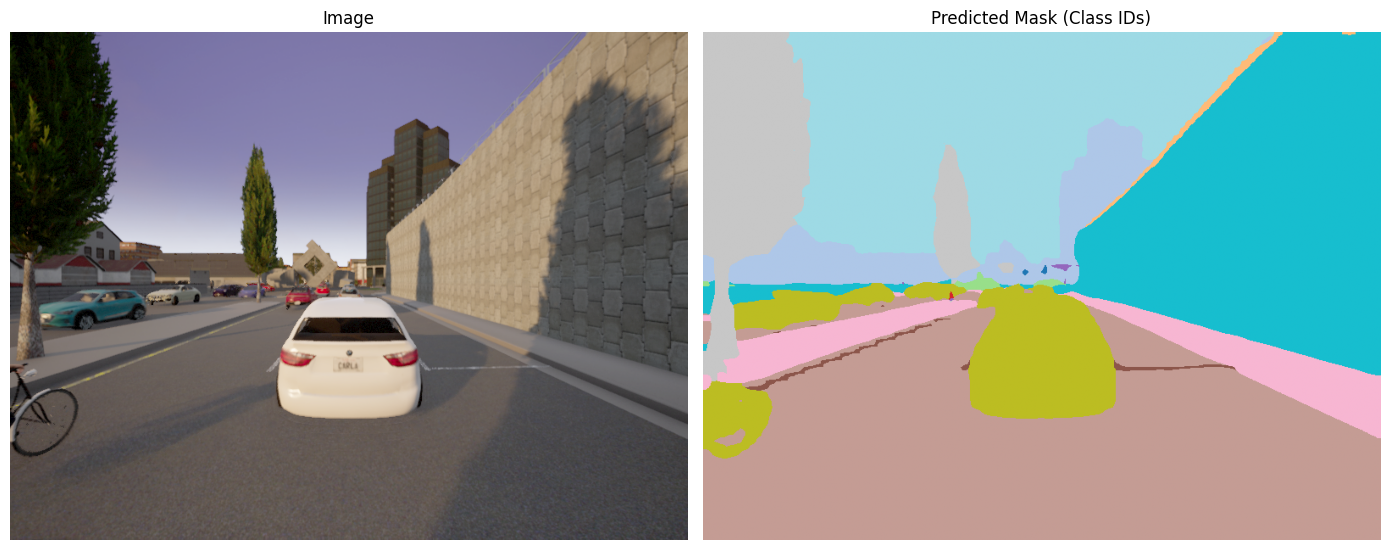

In [30]:
display_prediction(video=4, frame=0)

In [81]:
def hazard_level(area_ratio, bottom_ratio,
                 caution_area=0.03, stop_area=0.10,
                 caution_bottom=0.70, stop_bottom=0.82):

    if area_ratio >= stop_area or bottom_ratio >= stop_bottom:
        return "TOO CLOSE - STOP", (0, 0, 255)

    if area_ratio >= caution_area or bottom_ratio >= caution_bottom:
        return "GETTING CLOSE", (0, 255, 255)
        
    return "SAFE", (0, 255, 0)


In [66]:
def hazard_stats(pred_mask,
                 hazard_ids,
                 roi_x1=0.40, roi_x2=0.60,
                 roi_y1=0.55, roi_y2=1.00):

    H, W = pred_mask.shape
    x1 = int(roi_x1 * W); x2 = int(roi_x2 * W)
    y1 = int(roi_y1 * H); y2 = int(roi_y2 * H)

    roi = np.zeros((H, W), dtype=bool)
    roi[y1:y2, x1:x2] = True

    hazard_mask = np.isin(pred_mask, hazard_ids) & roi

    hazard_pixels = int(hazard_mask.sum())
    roi_pixels = int(roi.sum())
    area_ratio = hazard_pixels / float(roi_pixels)

    if hazard_pixels > 0:
        ys = np.where(hazard_mask)[0]
        bottom_ratio = ys.max() / float(H - 1)
    else:
        bottom_ratio = 0.0

    roi_box = (x1, y1, x2, y2)
    return area_ratio, bottom_ratio, hazard_pixels, roi_box


In [54]:
def display_prediction_with_warning(video, frame):
    img_path, _ = video_frames[video][frame]

    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    with torch.no_grad():
        x = torch.from_numpy(img_rgb).permute(2,0,1).float() / 255.0
        x = x.unsqueeze(0).to(device)
        output = model(x)["out"]
        pred_mask = output.argmax(1)[0].cpu().numpy()

    is_close, area_ratio, bottom_ratio, car_pixels, roi_box = car_closeness(
        pred_mask,
        car_id=10,
        area_thresh=0.12,
        bottom_thresh=0.80,
        roi_x1=0.40, roi_x2=0.60,
        roi_y1=0.55, roi_y2=1.00
    )

    vis_bgr = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR)

    x1, y1, x2, y2 = roi_box
    cv2.rectangle(vis_bgr, (x1, y1), (x2, y2), (255, 255, 255), 2)

    if is_close:
        msg = "YOU ARE CLOSE TO A VEHICLE - STOP"
        cv2.putText(vis_bgr, msg, (20, 50), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0,0,255), 3, cv2.LINE_AA)
    else:
        msg = "OK"
        cv2.putText(vis_bgr, msg, (20, 50), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0,200,0), 3, cv2.LINE_AA)

    dbg1 = f"car_pixels(ROI) = {car_pixels}"
    dbg2 = f"car_area(ROI) = {area_ratio*100:.2f}%   bottom = {bottom_ratio:.3f}"

    cv2.putText(vis_bgr, dbg1, (20, 85),  cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255,255,255), 2, cv2.LINE_AA)
    cv2.putText(vis_bgr, dbg2, (20, 115), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255,255,255), 2, cv2.LINE_AA)

    vis_rgb = cv2.cvtColor(vis_bgr, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(14,6))
    plt.subplot(1,2,1); plt.imshow(vis_rgb); plt.title("Image + Warning (ROI box)"); plt.axis("off")
    plt.subplot(1,2,2); plt.imshow(pred_mask, cmap="gray"); plt.title("Predicted Mask"); plt.axis("off")
    plt.tight_layout()
    plt.show()


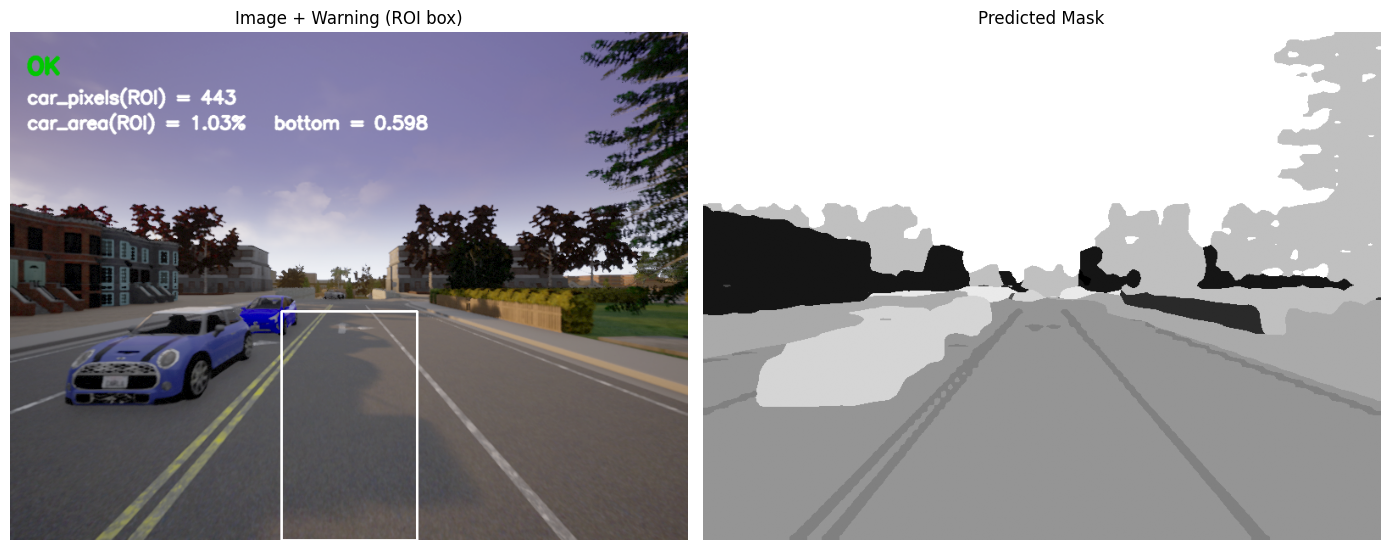

In [58]:
display_prediction_with_warning(video=0, frame=65)

In [82]:
def export_video_with_warnings(video,
                               hazard_ids,
                               out_path="output_warning.mp4",
                               fps=10,
                               roi_x1=0.40, roi_x2=0.60,
                               roi_y1=0.55, roi_y2=1.00,
                               caution_area=0.10, stop_area=0.78,
                               caution_bottom=0.78, stop_bottom=0.93,
                               max_frames=None):

    frames_list = video_frames[video]
    if max_frames is not None:
        frames_list = frames_list[:max_frames]

    if len(frames_list) == 0:
        raise ValueError("No frames found for this video index/key.")

    first_img_path, _ = frames_list[0]
    first = cv2.imread(first_img_path)
    if first is None:
        raise ValueError(f"Could not read first frame: {first_img_path}")

    H, W = first.shape[:2]

    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    writer = cv2.VideoWriter(out_path, fourcc, fps, (W, H))

    for i, (img_path, _) in enumerate(frames_list):

        img = cv2.imread(img_path)
        if img is None:
            continue

        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        with torch.no_grad():
            x = torch.from_numpy(img_rgb).permute(2,0,1).float() / 255.0
            x = x.unsqueeze(0).to(device)
            output = model(x)["out"]
            pred_mask = output.argmax(1)[0].cpu().numpy()

        area_ratio, bottom_ratio, hazard_pixels, roi_box = hazard_stats(
            pred_mask,
            hazard_ids=hazard_ids,
            roi_x1=roi_x1, roi_x2=roi_x2,
            roi_y1=roi_y1, roi_y2=roi_y2
        )

        msg, color = hazard_level(
            area_ratio, bottom_ratio,
            caution_area=caution_area,
            stop_area=stop_area,
            caution_bottom=caution_bottom,
            stop_bottom=stop_bottom
        )

        vis_bgr = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR)

        x1, y1, x2, y2 = roi_box
        cv2.rectangle(vis_bgr, (x1, y1), (x2, y2), color, 3)

        cv2.putText(vis_bgr, f"{msg}", (20, 50),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.9,
                    color, 3, cv2.LINE_AA)

        dbg1 = f"haz_pixels(ROI) = {hazard_pixels}"
        dbg2 = f"haz_area(ROI) = {area_ratio*100:.2f}%   bottom = {bottom_ratio:.3f}"

        cv2.putText(vis_bgr, dbg1, (20, 85),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7,
                    (255,255,255), 2, cv2.LINE_AA)

        cv2.putText(vis_bgr, dbg2, (20, 115),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7,
                    (255,255,255), 2, cv2.LINE_AA)

        writer.write(vis_bgr)

        if (i + 1) % 25 == 0:
            print(f"Processed {i+1}/{len(frames_list)} frames")

    writer.release()
    print("Saved:", out_path)


In [84]:
export_video_with_warnings(
    video=1,
    hazard_ids=[10, 4],
    out_path="video1_warning.mp4",
    fps=10
)

Processed 25/342 frames
Processed 50/342 frames
Processed 75/342 frames
Processed 100/342 frames
Processed 125/342 frames
Processed 150/342 frames
Processed 175/342 frames
Processed 200/342 frames
Processed 225/342 frames
Processed 250/342 frames
Processed 275/342 frames
Processed 300/342 frames
Processed 325/342 frames
Saved: video1_warning.mp4


In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = deeplabv3_resnet50(weights=None, num_classes=13)
model.load_state_dict(torch.load("deeplab_carla_BEST_MODEL.pth"))
model = model.to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

In [14]:
freq = classes_rgb["relative_percentile_frequency"].values.astype(np.float32) / 100.0

alpha = 0.5
weights = 1.0 / (freq ** alpha + 1e-8)

weights = weights / weights.mean()

class_weights = torch.tensor(weights, dtype=torch.float32).to(device)

print("Class weights:", class_weights.cpu().numpy())

criterion = torch.nn.CrossEntropyLoss(weight=class_weights)

Class weights: [4.0890613  0.24367303 1.7279441  1.6978906  0.9053337  1.0629011
 0.6704282  0.15727164 0.37803397 0.41821036 0.47990516 1.009722
 0.15962674]


In [16]:
def set_bn_eval(m):
    if isinstance(m, torch.nn.BatchNorm2d):
        m.eval()

In [22]:
scaler = torch.amp.GradScaler("cuda")